# Laomusic - Data Exploration Notebook

Notebook này khai phá chi tiết dữ liệu phục vụ xây dựng hệ thống gợi ý nhạc.

## Mục tiêu
- Kiểm tra chất lượng và độ phủ dữ liệu
- Hiểu hành vi tương tác user-song
- Đánh giá mức độ sử dụng được của feature content (artist/genre/language)
- Chuẩn bị insight cho 4 bài toán gợi ý trong `docs/project.md`

## 1) Cài đặt thư viện (nếu cần)
Chạy cell dưới nếu môi trường chưa có thư viện cần thiết.

In [48]:
# %pip install pandas sqlalchemy pymysql matplotlib seaborn python-dotenv

## 2) Nạp thư viện và kết nối DB
Dùng biến môi trường để bảo mật thông tin kết nối.

Đặt các biến sau trước khi chạy:
- `DB_URL` (đang JDBC như bạn cung cấp)
- `DB_USERNAME`
- `DB_PASSWORD`

In [49]:
import os
from urllib.parse import quote_plus, urlparse, parse_qsl, urlencode

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine, text

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

def jdbc_to_sqlalchemy_mysql(db_url: str, username: str, password: str) -> str:
    # Hỗ trợ cả 2 định dạng: jdbc:mysql://... và mysql://...
    if db_url.startswith('jdbc:'):
        db_url = db_url[5:]

    parsed = urlparse(db_url)
    if parsed.scheme != 'mysql':
        raise ValueError(f'Unsupported DB scheme: {parsed.scheme}')

    host = parsed.hostname
    port = parsed.port or 3306
    db_name = parsed.path.lstrip('/')
    if not host or not db_name:
        raise ValueError(f'Không parse được DB_URL: {db_url}')

    raw_qs = dict(parse_qsl(parsed.query, keep_blank_values=True))
    mapped_qs = {}

    # JDBC param useSSL -> PyMySQL param ssl_disabled
    if 'useSSL' in raw_qs:
        use_ssl = raw_qs['useSSL'].lower() == 'true'
        mapped_qs['ssl_disabled'] = str((not use_ssl)).lower()

    # Mặc định ổn định cho kết nối
    mapped_qs.setdefault('charset', 'utf8mb4')
    mapped_qs.setdefault('connect_timeout', '10')

    query = urlencode(mapped_qs)
    safe_user = quote_plus(username)
    safe_pass = quote_plus(password)
    return f'mysql+pymysql://{safe_user}:{safe_pass}@{host}:{port}/{db_name}?{query}'

dotenv_path = find_dotenv(usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path=dotenv_path, override=False)
    print('Loaded .env from:', dotenv_path)
else:
    print('Không tìm thấy .env theo thư mục hiện tại. Sẽ đọc trực tiếp biến môi trường hệ thống.')

DB_URL = os.getenv('DB_URL')
DB_USERNAME = os.getenv('DB_USERNAME')
DB_PASSWORD = os.getenv('DB_PASSWORD')

if not DB_URL or not DB_USERNAME or not DB_PASSWORD:
    raise EnvironmentError('Thiếu biến môi trường DB_URL / DB_USERNAME / DB_PASSWORD')

sqlalchemy_url = jdbc_to_sqlalchemy_mysql(DB_URL, DB_USERNAME, DB_PASSWORD)
engine = create_engine(sqlalchemy_url, pool_pre_ping=True)

with engine.connect() as conn:
    current_db = conn.execute(text('SELECT DATABASE()')).scalar()

print('Connected database:', current_db)

Loaded .env from: /Users/phuc/Coding/Git/Laomusic-recommendation/notebooks/.env
Connected database: tinamusic2


## 3) Khám phá tổng quan schema và kích thước bảng

In [50]:
tables_df = pd.read_sql(
    text('''
        SELECT table_name AS table_name, table_rows AS table_rows
        FROM information_schema.tables
        WHERE table_schema = DATABASE()
        ORDER BY table_rows DESC
    '''),
    engine
)
tables_df.columns = [str(c).lower() for c in tables_df.columns]
tables_df

,table_name,table_rows
0,audio_quality,230608
1,song,184240
2,interaction_song,134087
3,user_access_log,75697
4,artist_song,75110
5,playlist_song,31241
6,artist,23213
7,user,21781
8,genre_song,8575
9,interaction_playlist,5766


/var/folders/kn/6x6f54v10db9nt1tgj9m6wkw0000gn/T/ipykernel_98587/3559632847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='table_rows', y='table_name', palette='Blues_r')


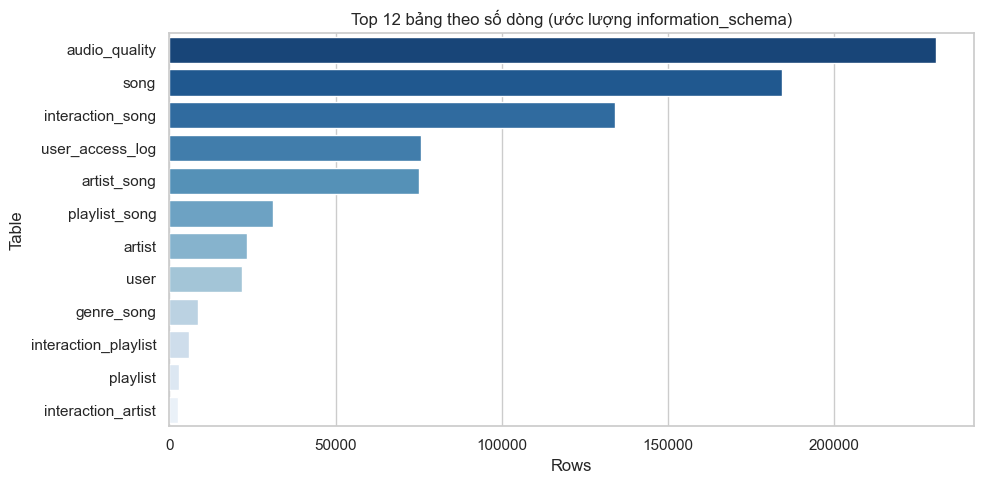

In [51]:
plt.figure(figsize=(10, 5))
plot_df = tables_df.head(12).copy()
sns.barplot(data=plot_df, x='table_rows', y='table_name', palette='Blues_r')
plt.title('Top 12 bảng theo số dòng (ước lượng information_schema)')
plt.xlabel('Rows')
plt.ylabel('Table')
plt.tight_layout()
plt.show()

## 4) Kiểm tra dữ liệu active (soft-delete) và độ phủ cột quan trọng

In [52]:
active_stats = pd.read_sql(text('''
SELECT 'song' AS entity, COUNT(*) AS total, SUM(deleted_at IS NULL) AS active FROM song
UNION ALL
SELECT 'artist', COUNT(*), SUM(deleted_at IS NULL) FROM artist
UNION ALL
SELECT 'playlist', COUNT(*), SUM(deleted_at IS NULL) FROM playlist
UNION ALL
SELECT 'user', COUNT(*), SUM(deleted_at IS NULL) FROM user
'''), engine)
active_stats['active_ratio'] = active_stats['active'] / active_stats['total']
active_stats

,entity,total,active,active_ratio
0,song,175155,71365.0,0.407439
1,artist,27368,27364.0,0.999854
2,playlist,2768,2582.0,0.932803
3,user,22928,22925.0,0.999869


In [53]:
song_quality = pd.read_sql(text('''
SELECT
    COUNT(*) AS total_active_songs,
    SUM(text_lyrics IS NULL OR text_lyrics = '') AS missing_text_lyrics,
    SUM(language IS NULL OR language = '') AS missing_language,
    SUM(duration IS NULL OR duration <= 0) AS missing_or_invalid_duration,
    SUM(release_date IS NULL) AS missing_release_date
FROM song
WHERE deleted_at IS NULL
'''), engine)

sq = song_quality.iloc[0]
quality_view = pd.DataFrame({
    'metric': [
        'missing_text_lyrics',
        'missing_language',
        'missing_or_invalid_duration',
        'missing_release_date'
    ],
    'count': [
        sq['missing_text_lyrics'],
        sq['missing_language'],
        sq['missing_or_invalid_duration'],
        sq['missing_release_date']
    ]
})
quality_view['ratio'] = quality_view['count'] / sq['total_active_songs']
quality_view.sort_values('ratio', ascending=False)

,metric,count,ratio
0,missing_text_lyrics,67572.0,0.946851
1,missing_language,35672.0,0.499853
3,missing_release_date,29607.0,0.414867
2,missing_or_invalid_duration,164.0,0.002298


## 5) Phân tích metadata bài hát (language, duration, audio quality)

In [54]:
song_language = pd.read_sql(text('''
SELECT
    COALESCE(NULLIF(language, ''), '__MISSING__') AS language,
    COUNT(*) AS song_count
FROM song
WHERE deleted_at IS NULL
GROUP BY COALESCE(NULLIF(language, ''), '__MISSING__')
ORDER BY song_count DESC
LIMIT 20
'''), engine)
song_language

,language,song_count
0,__MISSING__,35672
1,lo,13331
2,es,11865
3,fr,7883
4,zh,829
5,ko,773
6,none,606
7,th,204
8,ja,191
9,en,5


/var/folders/kn/6x6f54v10db9nt1tgj9m6wkw0000gn/T/ipykernel_98587/3755331980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=song_language.head(12), x='song_count', y='language', palette='crest')


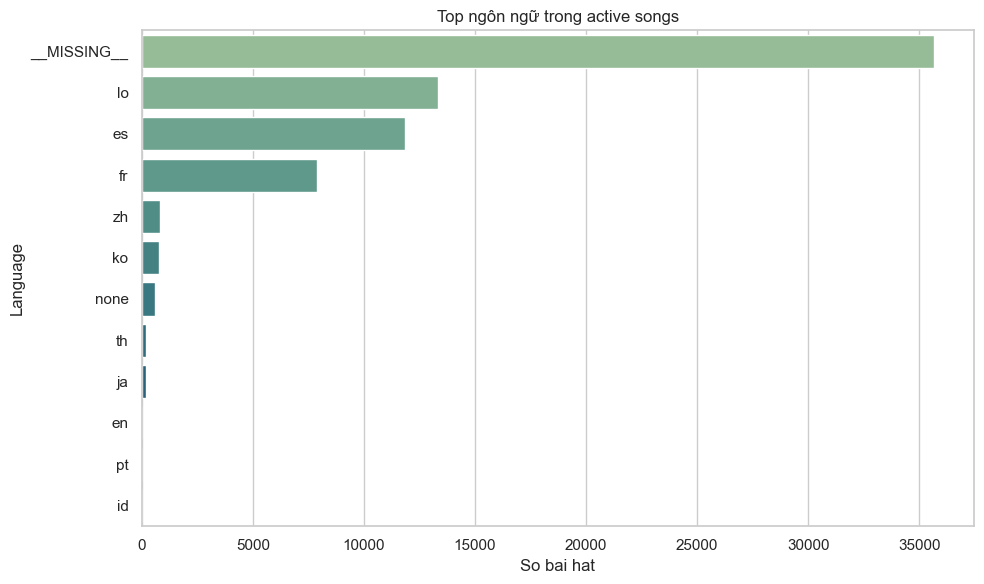

In [55]:
plt.figure(figsize=(10, 6))
sns.barplot(data=song_language.head(12), x='song_count', y='language', palette='crest')
plt.title('Top ngôn ngữ trong active songs')
plt.xlabel('So bai hat')
plt.ylabel('Language')
plt.tight_layout()
plt.show()

In [56]:
duration_df = pd.read_sql(text('''
SELECT duration
FROM song
WHERE deleted_at IS NULL AND duration IS NOT NULL AND duration > 0
'''), engine)

duration_df['duration_min'] = duration_df['duration'] / 60.0
duration_df['duration_min'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    71201.000000
mean         9.877634
std         28.966840
min          0.016667
50%          4.100000
75%          5.016667
90%         11.716667
95%         45.300000
99%        121.750000
max        722.733333
Name: duration_min, dtype: float64

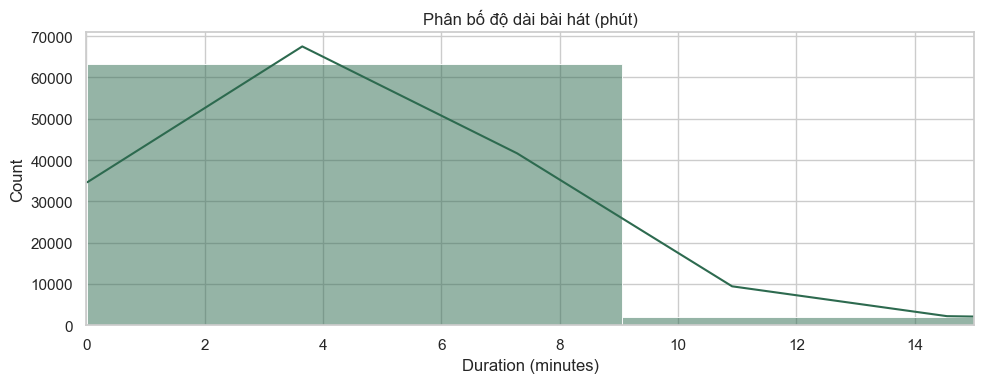

In [57]:
plt.figure(figsize=(10, 4))
sns.histplot(duration_df['duration_min'], bins=80, kde=True, color='#2d6a4f')
plt.xlim(0, 15)
plt.title('Phân bố độ dài bài hát (phút)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [58]:
audio_cov = pd.read_sql(text('''
SELECT
  (SELECT COUNT(DISTINCT song_id) FROM audio_quality) AS songs_with_audio,
  (SELECT COUNT(*) FROM song WHERE deleted_at IS NULL) AS active_songs
'''), engine)
audio_cov['audio_coverage_ratio_vs_active'] = audio_cov['songs_with_audio'] / audio_cov['active_songs']
audio_cov

,songs_with_audio,active_songs,audio_coverage_ratio_vs_active
0,124357,71365,1.742549


## 6) Phân tích graph content (artist-song, genre-song, playlist-song)

In [59]:
graph_stats = pd.read_sql(text('''
SELECT
  (SELECT COUNT(*) FROM artist_song) AS artist_song_edges,
  (SELECT COUNT(*) FROM genre_song) AS genre_song_edges,
  (SELECT COUNT(*) FROM playlist_song) AS playlist_song_edges
'''), engine)
graph_stats

,artist_song_edges,genre_song_edges,playlist_song_edges
0,67430,9165,31452


In [60]:
artist_per_song = pd.read_sql(text('''
SELECT c.artist_count, COUNT(*) AS song_count
FROM (
  SELECT s.id AS song_id, COUNT(a.id) AS artist_count
  FROM song s
  LEFT JOIN artist_song a ON s.id = a.song_id
  WHERE s.deleted_at IS NULL
  GROUP BY s.id
) c
GROUP BY c.artist_count
ORDER BY c.artist_count
'''), engine)
artist_per_song.head(15)

,artist_count,song_count
0,0,27346
1,1,42975
2,2,861
3,3,137
4,4,30
5,5,13
6,6,1
7,8,2


In [61]:
genre_per_song = pd.read_sql(text('''
SELECT c.genre_count, COUNT(*) AS song_count
FROM (
  SELECT s.id AS song_id, COUNT(g.id) AS genre_count
  FROM song s
  LEFT JOIN genre_song g ON s.id = g.song_id
  WHERE s.deleted_at IS NULL
  GROUP BY s.id
) c
GROUP BY c.genre_count
ORDER BY c.genre_count
'''), engine)
genre_per_song.head(15)

,genre_count,song_count
0,0,70127
1,1,1140
2,2,78
3,3,16
4,4,4


In [62]:
playlist_size = pd.read_sql(text('''
SELECT playlist_id, COUNT(*) AS songs_in_playlist
FROM playlist_song
GROUP BY playlist_id
'''), engine)
playlist_size.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,songs_in_playlist
count,2329.000000
mean,13.504508
std,21.816717
min,1.000000
50%,7.000000
75%,12.000000
90%,31.000000
95%,56.600000
99%,100.000000
max,308.000000


## 7) Phân tích interaction và behavioral signal

In [63]:
interaction_overview = pd.read_sql(text('''
SELECT
  COUNT(*) AS total_rows,
  COUNT(DISTINCT user_id) AS distinct_users,
  COUNT(DISTINCT song_id) AS distinct_songs
FROM interaction_song
'''), engine)
interaction_overview

,total_rows,distinct_users,distinct_songs
0,142348,80777,7643


In [64]:
action_dist = pd.read_sql(text('''
SELECT action_type, COUNT(*) AS cnt
FROM interaction_song
GROUP BY action_type
ORDER BY action_type
'''), engine)
action_dist['ratio'] = action_dist['cnt'] / action_dist['cnt'].sum()
action_dist

,action_type,cnt,ratio
0,0,131779,0.925752
1,1,7676,0.053924
2,2,720,0.005058
3,3,1790,0.012575
4,4,383,0.002691


/var/folders/kn/6x6f54v10db9nt1tgj9m6wkw0000gn/T/ipykernel_98587/2492045773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=action_dist, x='action_type', y='cnt', palette='mako')


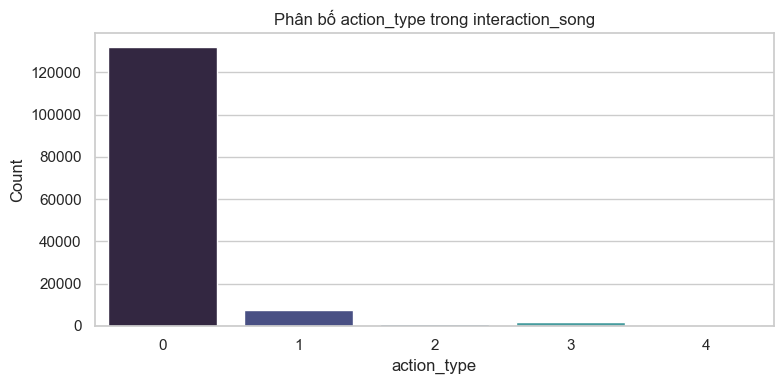

In [65]:
plt.figure(figsize=(8, 4))
sns.barplot(data=action_dist, x='action_type', y='cnt', palette='mako')
plt.title('Phân bố action_type trong interaction_song')
plt.xlabel('action_type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [66]:
user_activity = pd.read_sql(text('''
SELECT user_id, COUNT(*) AS interaction_count
FROM interaction_song
GROUP BY user_id
'''), engine)

user_activity['interaction_count'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    80777.000000
mean         1.762234
std         12.675637
min          1.000000
50%          1.000000
75%          1.000000
90%          1.000000
95%          1.000000
99%         14.000000
max       1064.000000
Name: interaction_count, dtype: float64

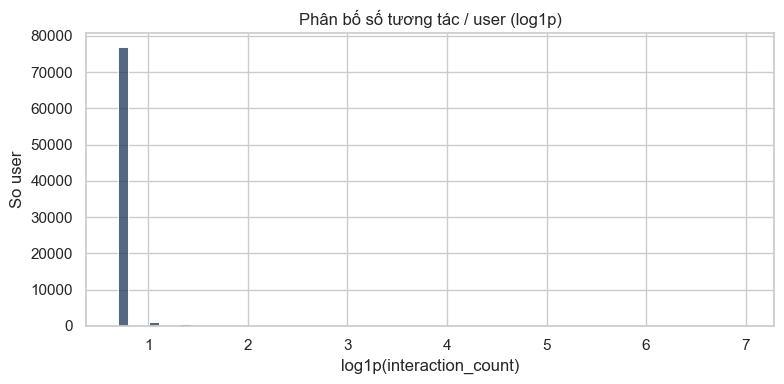

In [67]:
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(user_activity['interaction_count']), bins=60, color='#1d3557')
plt.title('Phân bố số tương tác / user (log1p)')
plt.xlabel('log1p(interaction_count)')
plt.ylabel('So user')
plt.tight_layout()
plt.show()

In [68]:
song_popularity = pd.read_sql(text('''
SELECT song_id, COUNT(*) AS interaction_count
FROM interaction_song
GROUP BY song_id
ORDER BY interaction_count DESC
'''), engine)

song_popularity.head(10)

,song_id,interaction_count
0,66bdc4ca-d773-40d1-a55f-4cd0cc3b577d,2468
1,0d7a75a0-90cd-44fd-bb2e-d8e84bcececf,2323
2,9421f1ad-738b-4728-b92a-c87e3376c0dc,2085
3,7b651817-8cfd-4226-8e94-340f9b62b215,2071
4,6efffdd7-cb33-4c40-9e64-7b1d9c44c0f9,2070
5,c1488e7d-83ee-4722-96b8-32c2c4e771a4,1832
6,c607921e-933f-4baa-8043-79eda58ad746,1524
7,2d091659-ebd3-4f73-8fc7-30db65022a7e,1097
8,bb7fd430-57ba-4c7a-99e7-7a7f1628a38c,1071
9,c39b0f82-1416-42ab-a40b-030f76de0644,1065


In [69]:
# Mức độ sparse user-item matrix
num_users = user_activity['user_id'].nunique()
num_items = song_popularity['song_id'].nunique()
num_interactions = int(interaction_overview.loc[0, 'total_rows'])
sparsity = 1 - (num_interactions / (num_users * num_items))

pd.DataFrame({
    'metric': ['users', 'items_with_interactions', 'interactions', 'matrix_sparsity'],
    'value': [num_users, num_items, num_interactions, sparsity]
})

,metric,value
0,users,80777.000000
1,items_with_interactions,7643.000000
2,interactions,142348.000000
3,matrix_sparsity,0.999769


In [70]:
# Kiểm tra tính nhất quán user_id interaction với bảng user
join_consistency = pd.read_sql(text('''
SELECT
  COUNT(*) AS interaction_rows,
  SUM(u.id IS NOT NULL) AS rows_join_user,
  SUM(u.id IS NULL) AS rows_not_join_user
FROM interaction_song i
LEFT JOIN user u ON i.user_id = u.id
'''), engine)
join_consistency['join_ratio'] = join_consistency['rows_join_user'] / join_consistency['interaction_rows']
join_consistency

,interaction_rows,rows_join_user,rows_not_join_user,join_ratio
0,142348,67504.0,74844.0,0.474218


## 8) Playlist và ranking signal

In [71]:
playlist_interaction_dist = pd.read_sql(text('''
SELECT action_type, COUNT(*) AS cnt
FROM interaction_playlist
GROUP BY action_type
ORDER BY action_type
'''), engine)
playlist_interaction_dist

,action_type,cnt
0,0,5442
1,1,384
2,2,108


In [72]:
artist_interaction_dist = pd.read_sql(text('''
SELECT action_type, COUNT(*) AS cnt
FROM interaction_artist
GROUP BY action_type
ORDER BY action_type
'''), engine)
artist_interaction_dist

,action_type,cnt
0,1,2350
1,2,333


In [73]:
ranking_dist = pd.read_sql(text('''
SELECT ranking_type, period, COUNT(*) AS cnt
FROM song_ranking
GROUP BY ranking_type, period
ORDER BY ranking_type, period
'''), engine)
ranking_dist.head(20)

,ranking_type,period,cnt
0,0,202515,70
1,0,202516,100
2,0,202517,100
3,0,202518,100
4,0,202519,100
5,0,202520,100
6,0,202521,100
7,0,202522,100
8,0,202523,100
9,0,202524,100


## 9) Candidate bộ dữ liệu modeling để huấn luyện
Tạo bộ interaction user-song có trọng số theo action để train CF/ALS/BPR hoặc item-item similarity.

In [74]:
# Giả sử mapping action_type -> trọng số (cần xác thực nghiệp vụ sau)
ACTION_WEIGHT = {
    0: 1.0,  # nghe / play
    1: 3.0,  # like
    2: 4.0,  # add_to_playlist
    3: 2.0,  # share
    4: 5.0,  # download / premium action
}

interactions = pd.read_sql(text('''
SELECT user_id, song_id, action_type, created_at
FROM interaction_song
'''), engine)

interactions['weight'] = interactions['action_type'].map(ACTION_WEIGHT).fillna(1.0)
interactions['created_at'] = pd.to_datetime(interactions['created_at'], errors='coerce')

# Gom interaction về cặp user-song
user_song_weight = (
    interactions.groupby(['user_id', 'song_id'], as_index=False)
    .agg(
        total_events=('action_type', 'count'),
        weighted_score=('weight', 'sum'),
        last_event=('created_at', 'max'),
    )
)

user_song_weight.head()

,user_id,song_id,total_events,weighted_score,last_event
0,00103473-7165-4427-80b4-edea97e3203f,9421f1ad-738b-4728-b92a-c87e3376c0dc,1,1.0,2026-04-06 07:58:09
1,00118475-c6a5-46b5-a51d-da708cd1e3a1,28ac9069-7ec2-4052-b33b-50343142cb8f,1,1.0,2026-01-04 10:44:15
2,00118475-c6a5-46b5-a51d-da708cd1e3a1,5d3f23dc-1536-468b-a047-1bbcd7e31a05,2,2.0,2026-01-04 10:42:55
3,00118475-c6a5-46b5-a51d-da708cd1e3a1,60691781-a351-4d8c-9fd5-3af3b780027a,1,1.0,2026-01-04 10:44:07
4,00118475-c6a5-46b5-a51d-da708cd1e3a1,e72dcbf1-d5b7-4fdf-b024-c9bbb30db9cb,1,1.0,2026-01-04 10:43:50


In [75]:
user_song_weight.describe(include='all')

,user_id,song_id,total_events,weighted_score,last_event
count,111771,111771,111771.000000,111771.000000,111771
unique,80777,7643,NaN,NaN,NaN
top,ddacb09e-4f70-4596-a737-882ce0b60491,66bdc4ca-d773-40d1-a55f-4cd0cc3b577d,NaN,NaN,NaN
freq,522,2335,NaN,NaN,NaN
mean,NaN,NaN,1.273568,1.459967,2025-12-25 09:48:38.673680640
min,NaN,NaN,1.000000,1.000000,2025-08-11 15:48:28
25%,NaN,NaN,1.000000,1.000000,2025-11-20 04:02:57
50%,NaN,NaN,1.000000,1.000000,2025-11-24 08:25:16
75%,NaN,NaN,1.000000,1.000000,2026-01-27 08:33:15
max,NaN,NaN,74.000000,74.000000,2026-05-13 04:17:16


## 10) Insight tự động cho đề xuất hệ thống

In [76]:
insight = {}
insight['active_songs'] = int(active_stats.loc[active_stats['entity']=='song', 'active'].iloc[0])
insight['interacted_songs'] = int(interaction_overview.loc[0, 'distinct_songs'])
insight['coverage_song_interactions'] = insight['interacted_songs'] / insight['active_songs']
insight['missing_language_ratio'] = float(quality_view.loc[quality_view['metric']=='missing_language', 'ratio'].iloc[0])
insight['missing_lyrics_ratio'] = float(quality_view.loc[quality_view['metric']=='missing_text_lyrics', 'ratio'].iloc[0])
insight['matrix_sparsity'] = float(sparsity)
insight


{'active_songs': 71365,
 'interacted_songs': 7643,
 'coverage_song_interactions': 0.10709731661178448,
 'missing_language_ratio': 0.4998528690534576,
 'missing_lyrics_ratio': 0.9468506971204372,
 'matrix_sparsity': 0.999769431597623}